#### imports

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                                roc_auc_score, average_precision_score, confusion_matrix)

import pickle


In [3]:
import warnings
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

#### load data

In [5]:
data = pd.read_csv(r'C:\Users\psxea2\Desktop\Amdari files\RederTelecom\EDA\clean_data2.csv')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12483 entries, 0 to 12482
Columns: 103 entries, Gender_Female to LastEmailClickedDate_Day
dtypes: float64(41), int64(62)
memory usage: 9.8 MB


In [7]:
data.columns

Index(['Gender_Female', 'Gender_Male', 'Frequency_Daily', 'Frequency_Monthly',
       'Frequency_Weekly', 'FirstActionType_Add to Cart',
       'FirstActionType_Click', 'FirstActionType_Search',
       'TotalInteractionType_Call', 'TotalInteractionType_Call,Chat',
       ...
       'most_recent_action_date_Day', 'LastEmailSentDate_Year',
       'LastEmailSentDate_Month', 'LastEmailSentDate_Day',
       'LastEmailOpenedDate_Year', 'LastEmailOpenedDate_Month',
       'LastEmailOpenedDate_Day', 'LastEmailClickedDate_Year',
       'LastEmailClickedDate_Month', 'LastEmailClickedDate_Day'],
      dtype='object', length=103)

In [8]:
x = data.drop(columns=['ChurnLabel'])
y = data[['ChurnLabel']]

In [9]:
y.value_counts(normalize=True)*100  #get class ratios

ChurnLabel
1             50.58079
0             49.41921
Name: proportion, dtype: float64

In [10]:
xcols=x.columns.to_list()

#### Standardize the data

In [11]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
standard_df = sc.fit_transform(x)
standard_df = pd.DataFrame(standard_df, columns =xcols)

In [12]:
x=standard_df.copy()

#### split data into train and test set

In [13]:
# split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### Training a base model: LR

In [14]:
#fit
lr = LogisticRegression()
lr.fit(x_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:

#predict
y_pred = lr.predict(x_test)

In [16]:
#predicted probabilities
y_pred_proba = lr.predict_proba(x_test)

In [17]:
#y_pred_proba

In [17]:
f1 = f1_score(y_test, y_pred)
accscore = accuracy_score(y_pred, y_test)
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
pr_auc = average_precision_score(y_test, y_pred_proba[:, 1])

print('Accuracy_score:', round(accscore*100, 2))
print('precision_score:', round(precision_score(y_pred,y_test)*100, 2)),
print('recall_score:', round(recall_score(y_pred,y_test)*100,2))
print("F1-score:", round(f1*100, 2))
print("ROC AUC:", round(roc_auc*100,2))
print("Precision–Recall AUC:", pr_auc)


#precision score before scaling:81.94, recall score:63.37

#accuracy score before scaling:67.64

Accuracy_score: 96.6
precision_score: 96.03
recall_score: 97.05
F1-score: 96.54
ROC AUC: 97.42
Precision–Recall AUC: 0.9649514365182921


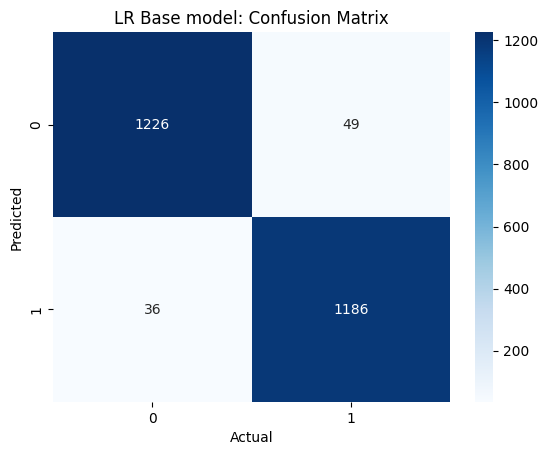

In [18]:
cm = confusion_matrix(y_pred, y_test)
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d')
plt.title('LR Base model: Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()



##### Hyperparameter tuning

{'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 100, 'C': 10}
Accuracy: 96.6
Precision: 97.05
Recall: 96.03
F1-score: 96.54
ROC AUC: 97.42
Precision–Recall AUC: 0.9649514365182921


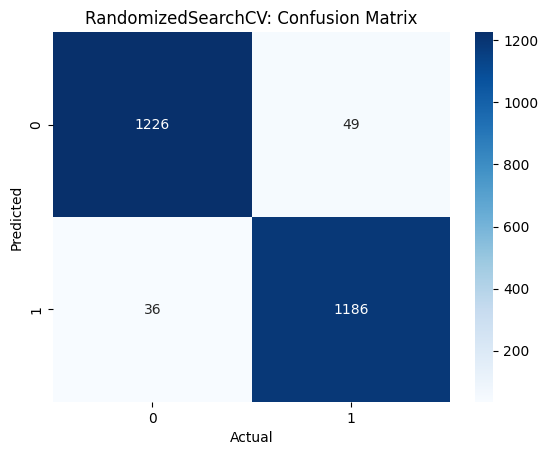

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

kfold_splitter = StratifiedKFold(n_splits=10)


param_dist = {
 'C':[0.001, 0.01, 0.1, 1, 10, 100],
'penalty':['l1','l2','elasticnet'],
'solver':['saga','sag','newton-cg', 'lbfgs', 'liblinear'],
'max_iter':[100, 200, 300]
}

model = LogisticRegression(n_jobs=1)
random_search = RandomizedSearchCV(model, param_distributions=param_dist, cv=kfold_splitter, random_state=666)

random_search.fit(x_train,y_train)
best_param = random_search.best_params_
best_model = random_search.best_estimator_

print(best_param)

y_pred = best_model.predict(x_test)

a_score = accuracy_score(y_test, y_pred)
p_score = precision_score(y_test, y_pred)
r_score = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
pr_auc = average_precision_score(y_test, y_pred_proba[:, 1])


print('Accuracy:', round(accuracy_score(y_test,y_pred)*100,2))
print('Precision:', round(precision_score(y_test,y_pred)*100,2))
print('Recall:', round(recall_score(y_test,y_pred)*100,2))
print("F1-score:", round(f1*100, 2))
print("ROC AUC:", round(roc_auc*100,2))
print("Precision–Recall AUC:", pr_auc)


cm = confusion_matrix(y_pred, y_test)
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d')
plt.title('RandomizedSearchCV: Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()



In [21]:
from sklearn.model_selection import GridSearchCV
kfold_splitter = StratifiedKFold(n_splits=10)

import json

parameter_grid = {
'C':[0.001, 0.01, 0.1, 1, 10, 100],
'penalty':['l1','l2','elasticnet'],
'solver':['saga','sag','newton-cg', 'lbfgs', 'liblinear'],
'max_iter':[100, 200, 300]
}

model = LogisticRegression(n_jobs=1)
grd_search = GridSearchCV(model, param_grid=parameter_grid, cv=kfold_splitter)

grd_search.fit(x_train,y_train)
best_param = grd_search.best_params_
best_model = grd_search.best_estimator_

print(best_param)


#save best model

with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

schema = {'model_schema': x.columns.tolist()}

with open('schema.json', 'w') as f:
    json.dump(schema, f)



{'C': 0.1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}


Accuracy: 96.76
Precision: 97.06
Recall: 96.36
F1-score: 96.71
ROC AUC: 97.42
Precision–Recall AUC: 0.9649514365182921


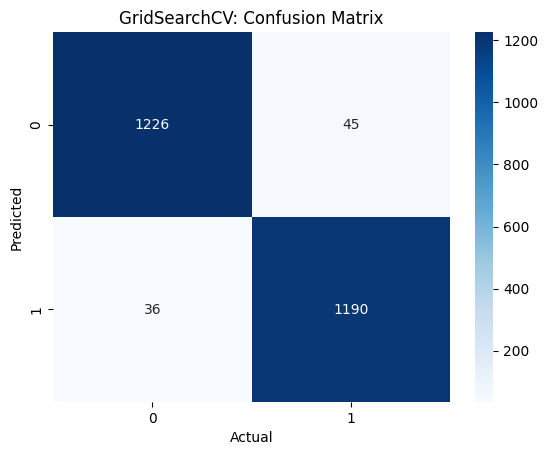

In [22]:


y_pred = best_model.predict(x_test)

acc_score = accuracy_score(y_test, y_pred)
prec_score = precision_score(y_test, y_pred)
rec_score = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
pr_auc = average_precision_score(y_test, y_pred_proba[:, 1])


print('Accuracy:', round(acc_score*100,2))
print('Precision:', round(prec_score*100,2))
print('Recall:', round(rec_score*100,2))
print("F1-score:", round(f1*100, 2))
print("ROC AUC:", round(roc_auc*100,2))
print("Precision–Recall AUC:", pr_auc)

cm = confusion_matrix(y_pred, y_test)
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d')
plt.title('GridSearchCV: Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()



##### inspecting feature selection for grid search cv best parameters

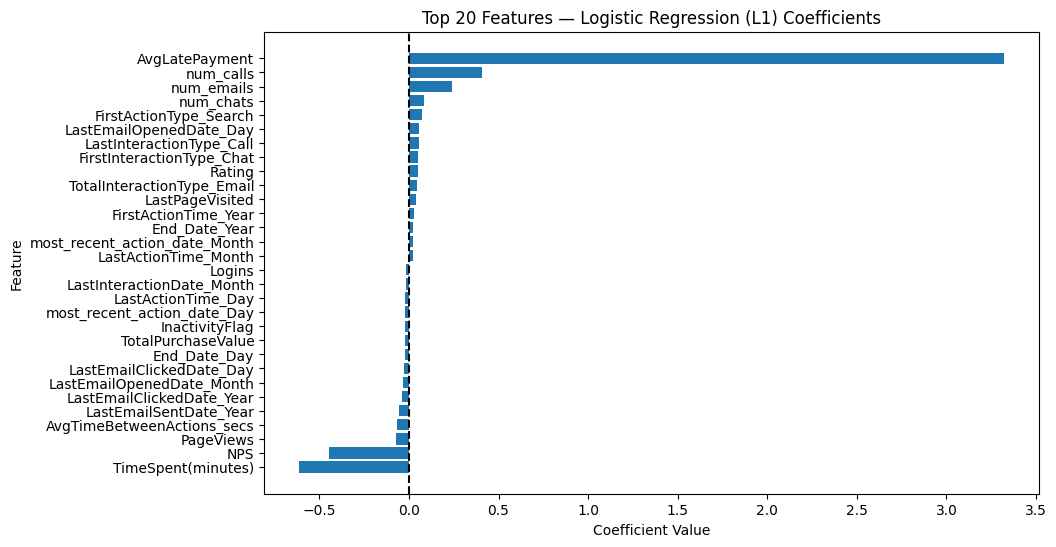

In [24]:
# Get the best model
best_model = grd_search.best_estimator_

# Extract coefficients
coeffs = best_model.coef_[0]
features = x_train.columns

# Put into a DataFrame
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coeffs,
    'Abs_Coefficient': np.abs(coeffs)
})

# Sort by importance
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# Filter non-zero only
nonzero_coef = coef_df[coef_df['Coefficient'] != 0]

# Select top 20
top30 = nonzero_coef.head(30).sort_values(by='Coefficient', ascending=True)

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(top30['Feature'], top30['Coefficient'])
plt.axvline(0, color='k', linestyle='--')
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top 20 Features — Logistic Regression (L1) Coefficients")
plt.show()

#### random forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(x_train, y_train)
y_pred = rfc.predict(x_test)

Accuracy: 97.20%
Precision: 97.09%
Recall: 97.25%
Precision–Recall AUC: 0.96
F1-score: 97.17
ROC AUC: 97.42


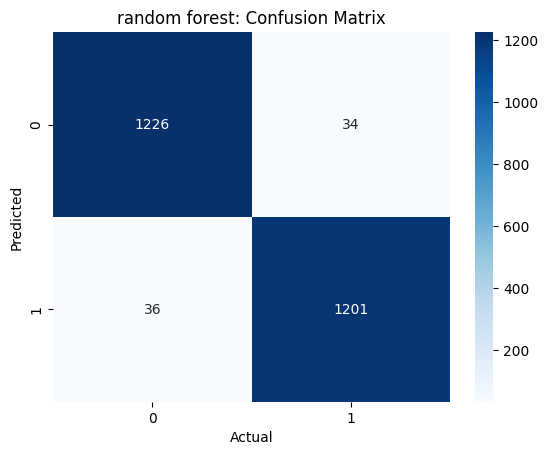

In [36]:

f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
pr_auc = average_precision_score(y_test, y_pred_proba[:, 1])

print(f'Accuracy: {accuracy_score(y_test,y_pred)*100:.2f}%')
print(f'Precision: {precision_score(y_test,y_pred)*100:.2f}%')
print(f'Recall: {recall_score(y_test,y_pred)*100:.2f}%')
print("Precision–Recall AUC:", round(pr_auc,2))
print("F1-score:", round(f1*100, 2))
print("ROC AUC:", round(roc_auc*100,2))

cm = confusion_matrix(y_pred, y_test)
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d')
plt.title('random forest: Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()
#scores before  scaling the data:  acc-97.24%, prec-97.09%, recall-97.33%